<h1> Two Moving Average Startegy <h1>

**Assumption:  
a. The commission is 3/10000 of the trade value per order.  
b. The starting money is 100000000.    
c. Trades in margin account are not permitted.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np
import matplotlib.dates as mdates

In [2]:
# Load the data
df = pd.read_csv('SPY_Daily.csv')

# Define the MA function
def simple_ma(T_prime, T):
    short_ma = df['Close'].rolling(window=T_prime).mean()
    long_ma = df['Close'].rolling(window=T).mean()
    return short_ma, long_ma

T_prime = 10
T = 50
# Calculate the moving averages
df['MA_T_prime'] = simple_ma(T_prime, T)[0]
df['MA_T'] = simple_ma(T_prime, T)[1]
df['Change'] = df['Close']-df['Close'].shift(1)

# Drop None and set index
df.dropna(inplace=True)
df=df.reset_index()
# Find the establish signals
df['Signal'] = np.where(df['MA_T_prime'] > df['MA_T'], 1, 0)
# Find the crossovers
df['Signalx'] = df['Signal'] - df['Signal'].shift(1)

In [3]:
df['Buy'] = np.where(df['Signalx'] == 1, df['Close'], np.nan)
df['Sell'] = np.where(df['Signalx'] == -1, df['Close'], np.nan)

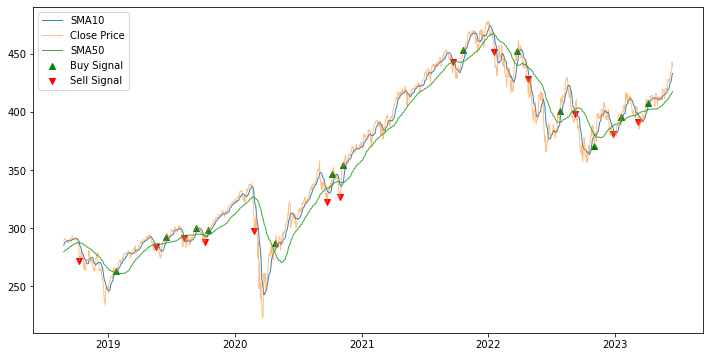

In [4]:
plt.figure(figsize=(12, 6)) 
xs = [datetime.datetime.strptime(d, '%Y-%m-%d').date() for d in df['DateTime']]
plt.plot(xs, df['MA_T_prime'], label = 'SMA10',  linewidth=1, alpha=0.9)
plt.plot(xs, df['Close'], label = 'Close Price',  linewidth=1, alpha=0.5)
plt.plot(xs, df['MA_T'], label = 'SMA50',  linewidth=1, alpha=0.9)
plt.scatter(xs, df['Buy'], color = 'green', label = 'Buy Signal', marker= '^')
plt.scatter(xs, df['Sell'], color = 'red', label = 'Sell Signal', marker= 'v')
plt.legend()

1. We start from simple MA(10) and MA(30).
$$
\text { Signal }=\left\{\begin{array}{l}
\text { Establish long position if } \mathrm{MA}\left(T^{\prime}\right)>\operatorname{MA}(T) \qquad 1\\
\text { Liquidate long position if } P<(1-\Delta) \times P_1\qquad\ \ \  2 \\
\text { Establish short position if } \mathrm{MA}\left(T^{\prime}\right)<\mathrm{MA}(T) \qquad3\\
\text { Liquidate short position if } P>(1+\Delta) \times P_1 \qquad\ \ \  4
\end{array}\right.
$$
In the first strategy, we establish 10000 asset when we meet long/short signal(1,3). Then we liquidate them all when we meet the stop-loss law(2,4).

In [5]:
def strategy1(df, positions = [0], balance = [100000000], P_previous = 0, threshold = 0.02, orders = []):    
    for i in range(len(df)):
        if df['Signalx'][i] == -1: # SM10 >SM30 => SM10 <SM30, short signal
            position = positions[-1] - 10000 # Position is limited to 10000
            money = balance[-1] + 10000 * df['Close'][i]
            order = 10000
        elif df['Signalx'][i] == 1: # SM10 <SM30 => SM10 >SM30, long signal
            position = positions[-1] + 10000
            money = balance[-1] - 10000 * df['Close'][i]
            order = 10000
        else:
            position = positions[-1]
            money = balance[-1]
            order = 0
        if df['Close'][i] < (1 - threshold) * P_previous and position > 0: # Reach the stop loss line, liquidate all long
            money = money + df['Close'][i] * position
            order = position
            position = 0
        elif df['Close'][i] > (1 + threshold) * P_previous and position < 0: # Reach the stop loss line, liquidate all short
            money = money + df['Close'][i] * position
            order  = position
            position = 0
        else:
            money = money
            position = position
            order = order
        balance.append(money)
        positions.append(position)
        P_previous=df['Close'][i]
        orders.append(order)
    df['Position'] = positions[1:] # We get the close price at the day after the present day, so we get the position from 1 not 0
    df['Position'] = df['Position'].shift(1)
    df['Cash'] = balance[0:-1]
    df['Order'] = orders
    df['PnL'] = df['Close'] * df['Position'] + df['Cash'] - 100000000 # Calculate PnL
    df['Net_PnL'] = df['PnL'] - 0.0003 * df['Order'] * df['Close'] # Get net PnL by mining commission
    df['Daily_PnL'] = df['Net_PnL'] - df['Net_PnL'].shift(1)
    return(df)

In [6]:
df1 = strategy1(df)

In [7]:
def performance(df):
    plt.figure(figsize=(12, 6)) 
    xs = [datetime.datetime.strptime(d, '%Y-%m-%d').date() for d in df['DateTime']]
    plt.plot(xs, df['Net_PnL'], label = 'Cumulative PnL')
    plt.legend()
    port_value = np.array(((df['Close'] * df['Position'] + df['Cash']).pct_change()).dropna())
    def get_max_drawdown(array):
        drawdowns = []
        max_so_far = array[0]
        for i in range(len(array)):
            if array[i] > max_so_far:
                drawdown = 0
                drawdowns.append(drawdown)
                max_so_far = array[i]
            else:
                drawdown = max_so_far - array[i]
                drawdowns.append(drawdown)
        return max(drawdowns)
    max_drawdown = get_max_drawdown(port_value)
    return(print('Strategy1: Cumulative PnL = ' + str(list(df1['Net_PnL'])[-1])),print('Strategy1: Max Drawdown = ' + str(max_drawdown)))

Strategy1: Cumulative PnL = -507300.0
Strategy1: Max Drawdown = 0.002746530128214908


(None, None)

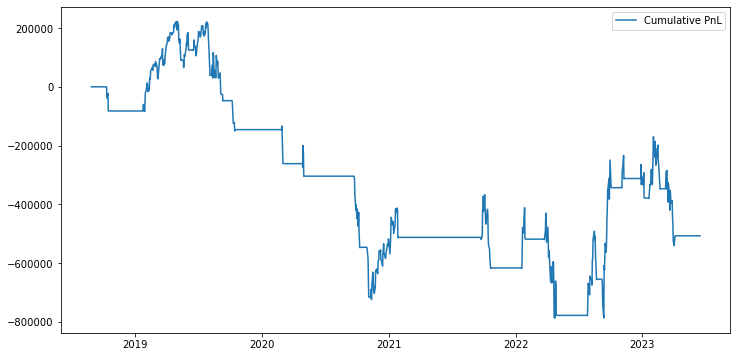

In [8]:
performance(df1)

In the second strategy, we establish as much asset as we can       
(remaining money/ current close)when we meet long/short signal(1,3). Then we liquidate them all when we meet the stop-loss law(2,4).

In [9]:
def strategy2(df, positions = [0], balance = [100000000], P_previous = 0, threshold = 0.02, orders = []):    
    for i in range(len(df)):
        if df['Signalx'][i] == -1: # SM10 >SM30 => SM10 <SM30, short signal
            order = balance[-1] // df['Close'][i] 
            position = positions[-1] - order 
            money = balance[-1] + order * df['Close'][i]
        elif df['Signalx'][i] == 1: # SM10 <SM30 => SM10 >SM30, long signal
            order = balance[-1] // df['Close'][i]
            position = positions[-1] + order
            money = balance[-1] - order * df['Close'][i]
        else:
            position = positions[-1]
            money = balance[-1]
            order = 0
        if df['Close'][i] < (1 - threshold) * P_previous and position > 0: # Reach the stop loss line, liquidate all long
            money = money + df['Close'][i] * position
            order = position
            position = 0
        elif df['Close'][i] > (1 + threshold) * P_previous and position < 0: # Reach the stop loss line, liquidate all short
            money = money + df['Close'][i] * position
            order  = -position
            position = 0
        else:
            money = money
            position = position
            order = order
        balance.append(money)
        positions.append(position)
        P_previous=df['Close'][i]
        orders.append(order)
    df['Position'] = positions[1:] # We get the close price at the day after the present day, so we get the position from 1 not 0
    df['Position'] = df['Position'].shift(1)
    df['Cash'] = balance[0:-1]
    df['Order'] = orders
    df['PnL'] = df['Close'] * df['Position'] + df['Cash'] - 100000000 # Calculate PnL
    df['Net_PnL'] = df['PnL'] - 0.0003 * df['Order'] * df['Close'] # Get net PnL by mining commission
    df['Daily_PnL'] = df['Net_PnL'] - df['Net_PnL'].shift(1)
    return(df)
    

In [10]:
df2=strategy2(df)

Strategy1: Cumulative PnL = -4450242.530000001
Strategy1: Max Drawdown = 0.07270079188385659


(None, None)

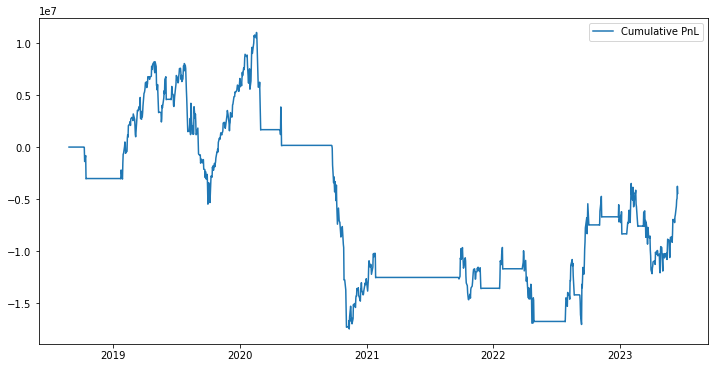

In [11]:
performance(df2)

In the third strategy, we establish as much asset as we can       
(remaining money/ current close)when we meet buy/sell signal(1,3). Then we liquidate 10000 when we meet the stop-loss law(2,4).

In [12]:
def strategy3(df, positions = [0], balance = [100000000], P_previous = 0, threshold = 0.02, orders = []):    
    for i in range(len(df)):
        if df['Signalx'][i] == -1: # SM10 >SM30 => SM10 <SM30, short signal
            order = balance[-1] // df['Close'][i] 
            position = positions[-1] - order 
            money = balance[-1] + order * df['Close'][i]
        elif df['Signalx'][i] == 1: # SM10 <SM30 => SM10 >SM30, long signal
            order = balance[-1] // df['Close'][i]
            position = positions[-1] + order
            money = balance[-1] - order * df['Close'][i]
        else:
            position = positions[-1]
            money = balance[-1]
            order = 0
        if df['Close'][i] < (1 - threshold) * P_previous and position > 0: # Reach the stop loss line, liquidate 1000 long
            money = money + df['Close'][i] * 1000
            order = 1000
            position = position - 1000
        elif df['Close'][i] > (1 + threshold) * P_previous and position < 0: # Reach the stop loss line, liquidate 1000 short
            money = money - df['Close'][i] * 1000
            order  =1000
            position = position + 1000
        else:
            money = money
            position = position
            order = order
        balance.append(money)
        positions.append(position)
        P_previous=df['Close'][i]
        orders.append(order)
    df['Position'] = positions[1:] # We get the close price at the day after the present day, so we get the position from 1 not 0
    df['Position'] = df['Position'].shift(1)
    df['Cash'] = balance[0:-1]
    df['Order'] = orders
    df['PnL'] = df['Close'] * df['Position'] + df['Cash'] - 100000000 # Calculate PnL
    df['Net_PnL'] = df['PnL'] - 0.0003 * df['Order'] * df['Close'] # Get net PnL by mining commission
    df['Daily_PnL'] = df['Net_PnL'] - df['Net_PnL'].shift(1)
    return(df)

In [13]:
df3=strategy3(df)

Strategy1: Cumulative PnL = 70617127.03999999
Strategy1: Max Drawdown = 0.18923275308918752


(None, None)

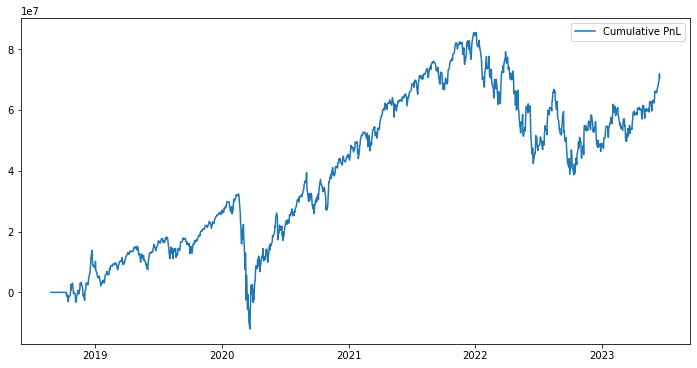

In [14]:
performance(df3)

In [17]:
def output(df):   
    df_Output = df.copy()
    df_Output = df.loc[:, ['DateTime', 'Daily_PnL']]
    df_Output.index=df_Output['DateTime']
    df_Output=df_Output.loc[:, 'Daily_PnL']
    return df_Output

In [18]:
o1 = output(df1)
o1.to_csv('PnL1.csv')
o2 = output(df2)
o2.to_csv('PnL2.csv')
o3 = output(df1)
o3.to_csv('PnL3.csv')